# PPO Evaluation: Market-only vs. Full Alpha

This notebook analyses the stored deterministic test rollouts of two separately trained PPO agents. The `market_only` agent uses Alpha scores from market features, while the `full_alpha` agent uses scores from market and fundamental features. The notebook does not train agents or recompute the evaluation.

## Evaluation contract

- Same chronological test split for both agents
- Same environment settings, costs, position limits, and deterministic rollout protocol
- The comparison concerns the trained PPO agent, not a direct Alpha-ranking rule portfolio
- Reported differences are descriptive and do not establish statistical superiority
- The source report is `eval/ppo_comparison.json`; run `pipeline/eval_ppo_comparison.py` before executing this notebook

In [20]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'eval').exists():
    ROOT = ROOT.parent
REPORT = ROOT / 'eval' / 'ppo_comparison.json'
if not REPORT.exists():
    raise FileNotFoundError(
        f'{REPORT} is missing. Run pipeline/eval_ppo_comparison.py first.'
    )
with REPORT.open(encoding='utf-8') as handle:
    report = json.load(handle)
metrics = pd.DataFrame.from_dict(
    {
        'market_only': report['market_only'],
        'full_alpha': report['full_alpha'],
    },
    orient='index',
)
delta = pd.Series(report['delta_full_minus_market'], name='full_minus_market')
baselines = pd.DataFrame.from_dict(report.get('baselines', {}), orient='index')
training = report.get('training', {})
assert set(metrics.index) == {'market_only', 'full_alpha'}
assert metrics['n_steps'].nunique() == 1, 'Die PPO-Agenten haben unterschiedliche Rollout-Längen.'
assert (metrics[['action_share_sell', 'action_share_hold', 'action_share_buy']].sum(axis=1).sub(1.0).abs() < 1e-8).all(), 'Aktionsanteile summieren sich nicht zu 1.'
assert metrics.apply(lambda column: column.map(pd.api.types.is_number).all()).all(), 'Report enthält nichtnumerische PPO-Metriken.'
# print(f'Report: {REPORT}')
print(f'Compared agents: {list(metrics.index)}')
print(f'Baselines: {list(baselines.index)}')
print(f'Training metadata available: {list(training)}')

Compared agents: ['market_only', 'full_alpha']
Baselines: ['buy_and_hold', 'equal_weight']
Training metadata available: ['market_only', 'full_alpha']


In [21]:
primary_metrics = [
    'cumulative_return', 'annualized_volatility', 'sharpe_ratio',
    'max_drawdown', 'mean_turnover', 'total_transaction_cost',
    'mean_reward', 'n_steps'
]
metrics[primary_metrics].T

,market_only,full_alpha
cumulative_return,0.166091,0.105807
annualized_volatility,0.360641,0.304958
sharpe_ratio,1.192983,0.923442
max_drawdown,-0.235787,-0.189996
mean_turnover,0.034386,0.037900
total_transaction_cost,3513.158904,3695.311642
mean_reward,0.001945,0.001399
n_steps,91.000000,91.000000


In [22]:
delta[primary_metrics].to_frame()

,full_minus_market
cumulative_return,-0.060283
annualized_volatility,-0.055683
sharpe_ratio,-0.269541
max_drawdown,0.045791
mean_turnover,0.003514
total_transaction_cost,182.152737
mean_reward,-0.000547
n_steps,0.000000


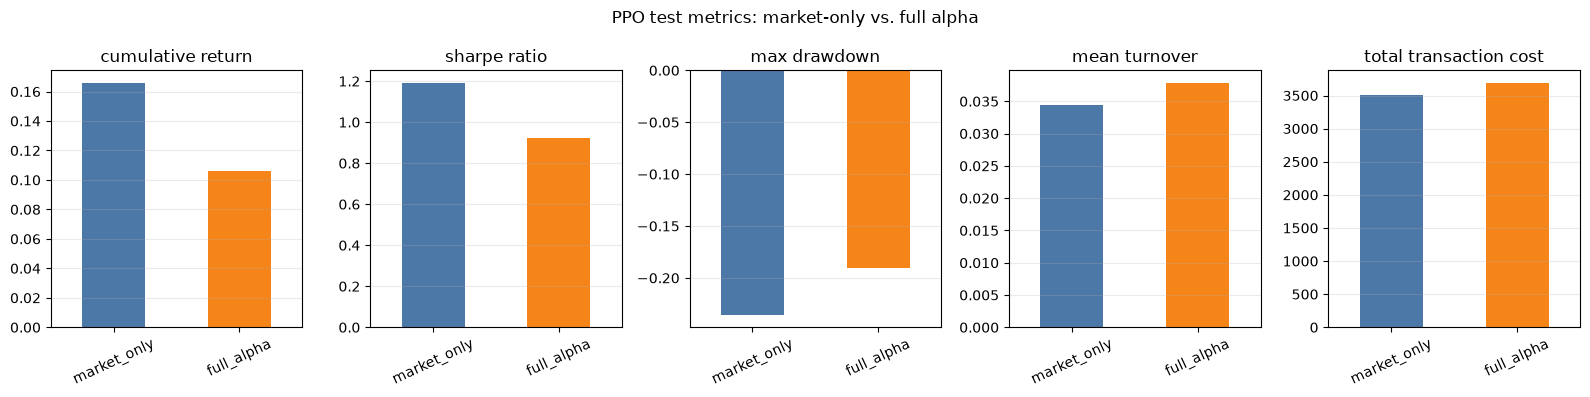

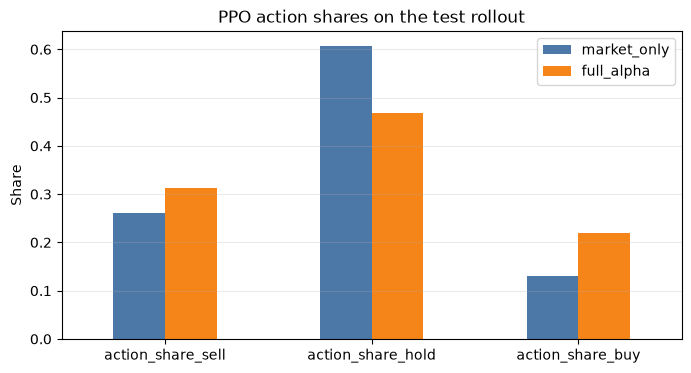

In [24]:
plot_metrics = ['cumulative_return', 'sharpe_ratio', 'max_drawdown', 'mean_turnover', 'total_transaction_cost']
fig, axes = plt.subplots(1, len(plot_metrics), figsize=(16, 4))
for axis, name in zip(axes, plot_metrics):
    metrics.loc[['market_only', 'full_alpha'], name].plot.bar(ax=axis, color=['#4C78A8', '#F58518'])
    axis.set_title(name.replace('_', ' '))
    axis.tick_params(axis='x', rotation=25)
    axis.grid(axis='y', alpha=0.25)
fig.suptitle('PPO test metrics: market-only vs. full alpha')
fig.tight_layout()
plt.show()

action_metrics = ['action_share_sell', 'action_share_hold', 'action_share_buy']
metrics.loc[['market_only', 'full_alpha'], action_metrics].T.plot.bar(figsize=(8, 4), color=['#4C78A8', '#F58518'])
plt.title('PPO action shares on the test rollout')
plt.ylabel('Share')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.25)
plt.show()

## Reference Portfolios

The buy-and-hold strategy starts with an equal-weighted position and does not rebalance thereafter. The equal-weight strategy rebalances daily. Both benchmarks are calculated from the test returns-excluding PPO transaction costs-and serve solely for contextual comparison. 

In [23]:
baseline_metrics = ['cumulative_return', 'annualized_volatility', 'sharpe_ratio', 'max_drawdown', 'n_steps']
baselines[baseline_metrics]

,cumulative_return,annualized_volatility,sharpe_ratio,max_drawdown,n_steps
buy_and_hold,0.253920,0.166769,3.757327,-0.087564,91
equal_weight,0.241433,0.135225,4.428853,-0.055545,91


## Policy activity diagnostics

This section reports two action levels for the residual PPO policy. The final action shares describe the executed Sell/Hold/Buy actions after composing the PPO residual with the Alpha rule. The residual shares describe the raw PPO choices Down/Keep/Up. Therefore, 100% residual Keep means that the agent follows the Alpha rule; it does not mean 100% final Hold. Turnover and transaction costs are reported alongside both views.

In [26]:
action_columns = ['action_share_sell', 'action_share_hold', 'action_share_buy']
residual_columns = [
    'residual_action_share_down',
    'residual_action_share_keep',
    'residual_action_share_up',
]
activity_rows = []

for agent in metrics.index:
    test_row = metrics.loc[agent]
    test_activity = float(test_row['action_share_sell'] + test_row['action_share_buy'])
    activity_rows.append({
        'agent': agent,
        'split': 'test',
        'sell_share': test_row['action_share_sell'],
        'hold_share': test_row['action_share_hold'],
        'buy_share': test_row['action_share_buy'],
        'active_share': test_activity,
        'residual_down_share': test_row.get('residual_action_share_down'),
        'residual_keep_share': test_row.get('residual_action_share_keep'),
        'residual_up_share': test_row.get('residual_action_share_up'),
        'mean_turnover': test_row['mean_turnover'],
        'transaction_cost': test_row['total_transaction_cost'],
    })

    training_entry = training.get(agent, {})
    training_metrics = training_entry.get('metrics') or {}
    validation = training_metrics.get('validation', {})
    if validation:
        validation_activity = float(
            validation.get('action_share_sell', 0.0)
            + validation.get('action_share_buy', 0.0)
        )
        activity_rows.append({
            'agent': agent,
            'split': 'validation',
            'sell_share': validation.get('action_share_sell'),
            'hold_share': validation.get('action_share_hold'),
            'buy_share': validation.get('action_share_buy'),
            'active_share': validation_activity,
            'residual_down_share': validation.get('residual_share_down'),
            'residual_keep_share': validation.get('residual_share_keep'),
            'residual_up_share': validation.get('residual_share_up'),
            'mean_turnover': validation.get('mean_turnover'),
            'transaction_cost': validation.get('total_transaction_cost'),
        })

policy_activity = pd.DataFrame(activity_rows)
policy_activity

,agent,split,sell_share,hold_share,buy_share,active_share,residual_down_share,residual_keep_share,residual_up_share,mean_turnover,transaction_cost
0,market_only,test,0.261538,0.607692,0.130769,0.392308,0.0,1.0,0.0,0.034386,3513.158904
1,market_only,validation,0.248936,0.566489,0.184574,0.433511,0.0,1.0,0.0,0.047637,4852.120874
2,full_alpha,test,0.312088,0.467582,0.220330,0.532418,0.0,1.0,0.0,0.037900,3695.311642
